# WaRP-S Semantic Segmentation — Mask2Former

Author: Umme-Yusrah Sumtally


---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/mask2former_warp_finetuned"

Mounted at /content/drive


In [ ]:
!pip install -q transformers==4.38.2 timm scipy Pillow matplotlib

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor, AdamW

import numpy as np
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATASET_ROOT = '/content/Waste-Classification/Dataset/raw/Warp-S'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.


Configs

In [ ]:
class_names = [
    'background','bottle-blue', 'bottle-blue-full', 'bottle-blue5l',
    'bottle-blue5l-full','bottle-dark', 'bottle-dark-full', 'bottle-green',
    'bottle-green-full','bottle-milk', 'bottle-milk-full', 'bottle-multicolor',
    'bottle-multicolorv-full', 'bottle-oil', 'bottle-oil-full','bottle-transp',
    'bottle-transp-full', 'bottle-yogurt', 'canister', 'cans', 'detergent-box',
    'detergent-color', 'detergent-transparent', 'detergent-white','glass-dark',
    'glass-green','glass-transp', 'juice-cardboard', 'milk-cardboard'
]

class_colors = [
    [0,0,0],[26,125,226], [4,43,131], [4,36,95], [6,42,185],[0,0,0], [4,10,10],
    [36,179,83], [54,246,37], [72,219,248],[9,65,170], [68,59,112], [104,90,172],
    [221,255,51], [226,253,87],[227,225,235], [243,237,243], [209,255,235],
    [51,51,248], [250,50,83], [39,39,39], [84,84,216], [231,228,231],[248,244,235],
    [21,22,25],[45,250,45], [236,235,250],[126,195,149], [103,199,218]
]

id_to_label={i:name for i,name in enumerate(class_names)}
label_to_id ={name:i for i,name in enumerate(class_names)}
NUM_CLASSES= len(class_names)

Class and fucntions

In [ ]:
class WarpDataset(Dataset):
    def __init__(self, root_dir, processor):
        self.root=Path(root_dir)
        self.processor= processor
        self.img_dir =self.root /'JPEGImages'
        self.mask_dir =self.root/'SegmentationClass'
        self.images=sorted(list(self.img_dir.glob('*.jpg'))+list(self.img_dir.glob('*.png')))

        self.color_map = [
            [0,0,0], [26,125,226], [4,43,131], [4,36,95], [6,42,185],[0,0,0], [4,10,10],
            [36,179,83], [54,246,37],[72,219,248], [9,65,170], [68,59,112], [104,90,172],
            [221,255,51],[226,253,87],[227,225,235], [243,237,243], [209,255,235],
            [51,51,248], [250,50,83], [39,39,39], [84,84,216], [231,228,231], [248,244,235],
            [21,22,25],[45,250,45], [236,235,250], [126,195,149], [103,199,218]
        ]

    def __len__(self):
        return len(self.images)

    #Maps the RGB colors to class index
    def rgb_to_id(self, mask_rgb):
        mask_rgb = np.array(mask_rgb)
        h,w, _= mask_rgb.shape
        mask_id =np.zeros((h,w), dtype=np.uint8)

        for i,color in enumerate(self.color_map):
            match =np.all(mask_rgb==color,axis=-1)
            mask_id[match]= i
        return mask_id

    def __getitem__(self, idx):
        img_path= self.images[idx]
        mask_path= self.mask_dir/(img_path.stem + '.png')

        image=Image.open(img_path).convert("RGB")
        mask_rgb= Image.open(mask_path).convert("RGB")
        mask_np=self.rgb_to_id(mask_rgb)

        inputs = self.processor(images=image, segmentation_maps=mask_np, return_tensors="pt")
        return {
            "pixel_values":inputs["pixel_values"][0],  "mask_labels":inputs["mask_labels"][0], "class_labels": inputs["class_labels"][0]
        }

In [ ]:
#this method stack only pixel values in one tensor.
def stack_tensor(batch):
    pixel_val= []
    mask_lbls= []
    class_labels=[]

    for entry in batch:
        pixel_val.append(entry["pixel_values"])
        mask_lbls.append(entry["mask_labels"])
        class_labels.append(entry["class_labels"])

    pixel_val= torch.stack(pixel_val)

    return {
        "pixel_values": pixel_val,  "mask_labels": mask_lbls,
        "class_labels": class_labels
    }

In [ ]:
#maping predicted class Index to RGB values so that we can visualize the prediction as image.
def label_to_color_image(label_map):
    h,w = label_map.shape
    image=np.zeros((h, w, 3), dtype=np.uint8)

    for label_id, color in enumerate(class_colors):
        image[label_map== label_id]=color

    return image

In [ ]:
import matplotlib.pyplot as plt

#Switched the model from train to eval mode and show a snapshot of model's prediction - then go back to training mode again.
%matplotlib inline
def test_and_show(model, dataset, epoch_num):
    model.eval()
    item =dataset[0]
    pixel_values=item["pixel_values"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs= model(pixel_values=pixel_values)

    result=processor.post_process_semantic_segmentation(outputs, target_sizes=[(384, 384)])[0]
    predicted_mask= result.cpu().numpy()
    color_mask =label_to_color_image(predicted_mask)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    img_display= item["pixel_values"].permute(1, 2, 0).cpu().numpy()
    img_display= (img_display-img_display.min())/(img_display.max()- img_display.min())
    plt.imshow(img_display)
    plt.title(f"Original Image (Epoch {epoch_num})")

    plt.subplot(1,2, 2)
    plt.imshow(color_mask)
    plt.title("Model Prediction")
    plt.show()

    model.train()

Model Training + Visualisation

In [ ]:
base_path="facebook/mask2former-swin-base-ade-semantic"

processor= Mask2FormerImageProcessor.from_pretrained(base_path)
Mask2Former_model= Mask2FormerForUniversalSegmentation.from_pretrained(
    base_path,  num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

Mask2Former_model.config.id2label =id_to_label
Mask2Former_model.config.label2id=label_to_id

Mask2Former_model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/432M [00:00<?, ?B/s]

Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([30]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([30, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([30]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


/usr/local/lib/python3.12/dist-packages/transformers/optimization.py:429: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1 | Loss: 74.1716
Epoch 2 | Loss: 49.4923
Epoch 3 | Loss: 43.0236
Epoch 4 | Loss: 39.6761
Epoch 5 | Loss: 37.0596


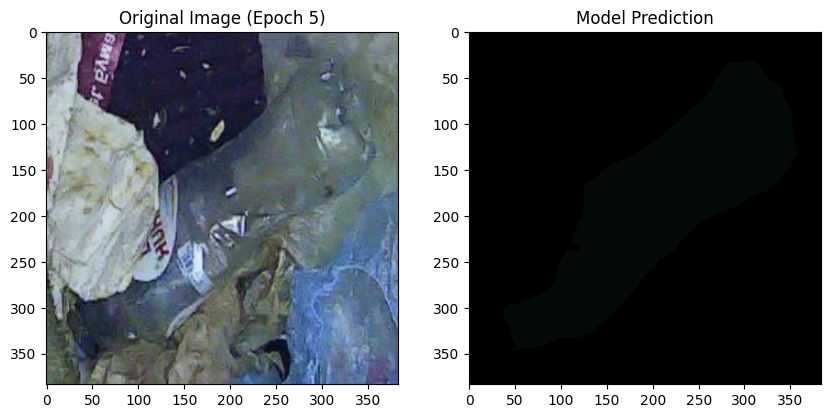

Epoch 6 | Loss: 35.8914
Epoch 7 | Loss: 35.0714
Epoch 8 | Loss: 30.9840
Epoch 9 | Loss: 32.5208
Epoch 10 | Loss: 30.5794


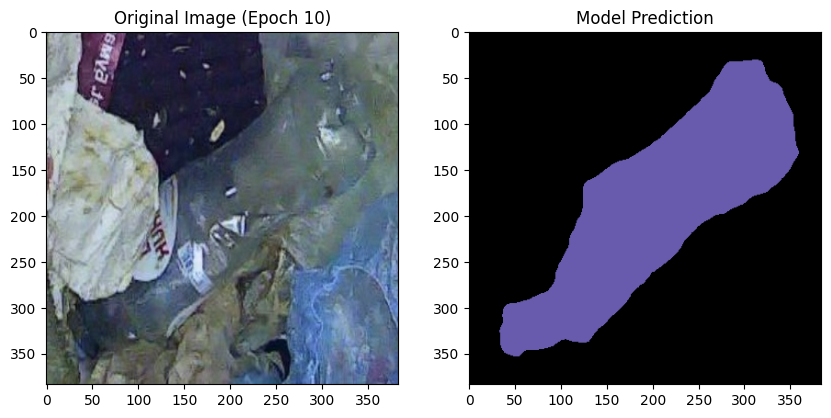

Epoch 11 | Loss: 27.2157
Epoch 12 | Loss: 28.8297
Epoch 13 | Loss: 25.0466
Epoch 14 | Loss: 23.5817
Epoch 15 | Loss: 22.7710


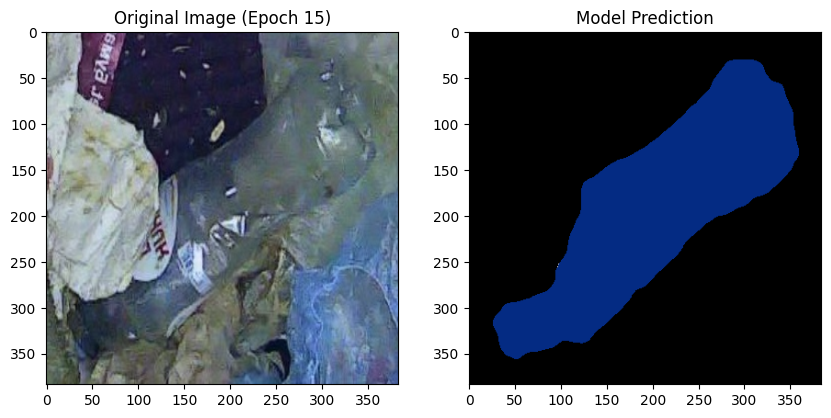

In [ ]:
train_dataset = WarpDataset(DATASET_ROOT, processor)
train_loader =DataLoader(
    train_dataset,  batch_size=2,
    shuffle=True,
    collate_fn= stack_tensor
)

LR= 5e-5
WEIGHT_DECAY=0.05
optimizer = AdamW(Mask2Former_model.parameters(), lr=5e-5, weight_decay=0.05)
Mask2Former_model.train()

Number_of_epochs = 15
for epoch in range(Number_of_epochs):
    total_loss = 0
    for batch in train_loader:

        pixel_values =batch["pixel_values"].to(DEVICE)
        mask_labels= [l.to(DEVICE) for l in batch["mask_labels"]]
        class_labels=[l.to(DEVICE) for l in batch["class_labels"]]

        optimizer.zero_grad()

        outputs =Mask2Former_model(
            pixel_values=pixel_values,mask_labels=mask_labels,  class_labels=class_labels
        )

        epch_loss=outputs.loss
        epch_loss.backward()
        optimizer.step()

        total_loss +=epch_loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")


    if (epoch + 1) % 5 ==0:
        test_and_show(Mask2Former_model, train_dataset, epoch + 1)

In [ ]:
Mask2Former_model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)

print(f"Model saved: {SAVE_PATH}")

Model saved: /content/drive/MyDrive/mask2former_warp_finetuned


Metrics

In [ ]:
import numpy as np
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support

def get_comprehensive_metrics(model, dataset):
    model.eval()
    all_ious= []
    all_precisions= []
    all_recalls= []
    all_f1s= []


    for idx in tqdm(range(len(dataset))):
        img_examp = dataset[idx]
        pixel_values = img_examp["pixel_values"].unsqueeze(0).to(DEVICE)

        img_path =dataset.images[idx]
        mask_path=dataset.mask_dir/(img_path.stem + '.png')
        gt_mask =dataset.rgb_to_id(Image.open(mask_path).convert("RGB"))

        with torch.no_grad():
            outputs=model(pixel_values=pixel_values)

        target_size= gt_mask.shape
        result =processor.post_process_semantic_segmentation(outputs,target_sizes=[target_size])[0]
        pred_mask =result.cpu().numpy()

        gt_flat=gt_mask.flatten()
        pred_flat= pred_mask.flatten()

        p,r,f1, _= precision_recall_fscore_support(gt_flat, pred_flat, average='weighted', zero_division=0)
        all_precisions.append(p)
        all_recalls.append(r)
        all_f1s.append(f1)

        for cls_col in range(len(class_colors)):
            intersection= np.logical_and(gt_mask==cls_col, pred_mask==cls_col).sum()
            union=np.logical_or(gt_mask ==cls_col, pred_mask==cls_col).sum()
            if union >0:
                all_ious.append(intersection/union)

    print('\n')
    print(f"Mean IoU (mIoU):   {np.mean(all_ious):.4f}")
    print(f"Mean Precision:    {np.mean(all_precisions):.4f}")
    print(f"Mean Recall:       {np.mean(all_recalls):.4f}")
    print(f"Mean F1-Score:     {np.mean(all_f1s):.4f}")

get_comprehensive_metrics(Mask2Former_model, train_dataset)

100%|██████████| 112/112 [00:56<00:00,  1.98it/s]



Mean IoU (mIoU):   0.4605
Mean Precision:    0.6970
Mean Recall:       0.6883
Mean F1-Score:     0.6834
